# Cuaderno de limpieza de Pedro Herrero Bas

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv('../../data/processed/dataset_final.csv')
df

,año,com_aut,pib,pob,sui,nat,paro,ing,homi,pib_pc,...,retrasos_pagos(%),renta_media,renta_mediana,riesgo_pobreza(%),dificultad_fin_mes(%),desigualdad_ing(S80/S20),inc_gastos_imprevistos(%),tasa_criminalidad,precio_medio_anual_eur_m2_venta,precio_medio_anual_eur_m2_alquiler
0,2009,Andalucía,145802256.0,8244.5,10.87,11.48,17.73,9437.0,0.94,17685.0,...,10.6,143930.0,126950.0,27.7,71.8,6.0,45.7,49.3,1757.50,7.27
1,2010,Andalucía,145853901.0,8302.9,9.89,11.10,25.24,9882.0,0.94,17567.0,...,12.9,141520.0,120860.0,28.1,73.9,6.2,52.2,49.3,1713.33,6.85
2,2011,Andalucía,144494494.0,8352.8,8.84,10.72,27.77,9793.0,1.02,17299.0,...,13.8,13310.0,113690.0,34.5,70.5,7.3,49.6,48.7,1723.42,6.72
3,2012,Andalucía,139052618.0,8378.3,8.30,10.30,30.13,9241.0,0.81,16597.0,...,15.5,133910.0,111170.0,35.6,71.6,6.2,51.4,47.1,1579.42,6.43
4,2013,Andalucía,137294091.0,8381.3,9.78,9.71,34.35,9361.0,0.78,16381.0,...,13.4,127050.0,108660.0,40.1,75.4,6.6,55.5,44.6,1443.42,6.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,2018,Rioja,8649852.0,314.9,7.62,7.45,12.00,12561.0,0.32,27470.0,...,7.9,17490.0,15410.0,19.1,37.8,5.7,30.3,26.3,1180.17,5.89
262,2019,Rioja,8889997.0,317.0,6.11,7.66,10.40,12589.0,0.00,28040.0,...,4.9,186610.0,165770.0,17.5,25.4,5.0,19.0,27.6,1205.67,6.21
263,2020,Rioja,8186915.0,319.1,8.75,7.33,9.96,13371.0,1.57,25654.0,...,8.2,196980.0,175890.0,16.9,27.7,4.7,24.5,24.5,1215.08,6.58
264,2021,Rioja,8735750.0,319.2,8.27,6.94,10.80,14303.0,0.94,27365.0,...,8.0,187580.0,17420.0,16.8,32.3,5.1,22.5,28.6,1238.25,6.83


In [99]:
df['pib_pc'] = df['pib'] / df['poblacion']
df = df.drop(columns='pob')

In [100]:
def filtrar_columna(df:pd.DataFrame, columna:str):
    '''
    Función para dividir un Dataset, en una lista de Dataset según los valores de una columna.
    '''
    lista_df = []
    lista_valores = df[columna].unique().tolist()
    for valor in lista_valores:
        lista_df.append(df[df[columna] == valor].set_index(columna))
    return lista_df

In [101]:
df_com = filtrar_columna(df, 'com_aut')

In [102]:
df_com[0].index[0]

'Andalucía'

In [103]:
corr_matrices = {df.index[0]: df.corr() for df in df_com}
len(corr_matrices)

19

In [104]:
corr_matrices['Madrid']

,año,pib,sui,nat,paro,ing,homi,pib_pc,renta_pc,poblacion,...,retrasos_pagos(%),renta_media,renta_mediana,riesgo_pobreza(%),dificultad_fin_mes(%),desigualdad_ing(S80/S20),inc_gastos_imprevistos(%),tasa_criminalidad,precio_medio_anual_eur_m2_venta,precio_medio_anual_eur_m2_alquiler
año,1.000000,0.879551,0.767841,-0.991715,-0.250544,0.633040,-0.666939,0.763119,0.870661,0.978688,...,0.080462,-0.375323,0.141825,0.065456,-0.806817,-0.020099,-0.710619,-0.625039,0.406156,0.820098
pib,0.879551,1.000000,0.637166,-0.858562,-0.488500,0.645768,-0.408845,0.977662,0.966251,0.801787,...,0.079173,-0.351955,0.284020,-0.194836,-0.847905,-0.108253,-0.762478,-0.259893,0.617397,0.875347
sui,0.767841,0.637166,1.000000,-0.709251,-0.121161,0.211609,-0.675079,0.526360,0.668769,0.795074,...,0.035206,-0.311710,-0.184580,0.331226,-0.596599,0.287182,-0.731247,-0.532578,0.062051,0.570797
nat,-0.991715,-0.858562,-0.709251,1.000000,0.288884,-0.673566,0.641547,-0.739540,-0.853140,-0.969187,...,-0.116804,0.391257,-0.199659,-0.010617,0.817848,0.100382,0.693781,0.655585,-0.452823,-0.841102
paro,-0.250544,-0.488500,-0.121161,0.288884,1.000000,-0.445976,-0.235256,-0.566552,-0.558357,-0.148984,...,-0.385670,0.150946,-0.504230,0.707602,0.673924,0.426846,0.694236,0.128333,-0.783575,-0.697691
ing,0.633040,0.645768,0.211609,-0.673566,-0.445976,1.000000,-0.005811,0.635147,0.652901,0.495436,...,0.465343,-0.219386,0.443621,-0.626437,-0.660453,-0.640416,-0.427315,-0.486202,0.836781,0.668694
homi,-0.666939,-0.408845,-0.675079,0.641547,-0.235256,-0.005811,1.000000,-0.246109,-0.440837,-0.768660,...,0.228380,0.447272,0.408415,-0.623751,0.354885,-0.364924,0.446562,0.487274,0.214364,-0.345907
pib_pc,0.763119,0.977662,0.526360,-0.739540,-0.566552,0.635147,-0.246109,1.000000,0.937258,0.658436,...,0.110685,-0.313234,0.335873,-0.322132,-0.808263,-0.165928,-0.729789,-0.101273,0.688380,0.832869
renta_pc,0.870661,0.966251,0.668769,-0.853140,-0.558357,0.652901,-0.440837,0.937258,1.000000,0.800765,...,0.104490,-0.431845,0.282345,-0.230687,-0.925617,-0.091800,-0.857632,-0.363848,0.640937,0.917703
poblacion,0.978688,0.801787,0.795074,-0.969187,-0.148984,0.495436,-0.768660,0.658436,0.800765,1.000000,...,-0.037139,-0.370348,0.057222,0.221345,-0.745716,0.098674,-0.670941,-0.644724,0.248656,0.772611


In [105]:
def corr_to_vector(corr_df):
    '''Convierte una matriz de correlación en un vector de una dimensión con todos los valores cruzados.'''
    return (corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack())

# DataFrame: filas = datasets, columnas = pares de variables
corr_vectors = pd.DataFrame([corr_to_vector(matriz) for matriz in corr_matrices.values()])

corr_vectors.index = [key for key in corr_matrices.keys()]
corr_vectors

año                                          \
                           pib       sui       nat      paro       ing   
Andalucía             0.796477 -0.469589 -0.992357 -0.253891  0.307417   
Aragón                0.805034  0.326137 -0.986057 -0.271785  0.657572   
Asturias              0.554838  0.173727 -0.981548 -0.107164  0.382205   
Balears               0.739768 -0.657127 -0.982874 -0.408335  0.484590   
Canarias              0.614250  0.236305 -0.980841 -0.299342  0.515176   
Cantabria             0.742284  0.537352 -0.996174 -0.116096  0.459939   
Castilla - La Mancha  0.723787 -0.027022 -0.991296 -0.168516  0.336975   
Castilla Y León       0.715210  0.442991 -0.990941 -0.278922  0.780713   
Cataluña              0.849957  0.652973 -0.991957 -0.379584  0.706280   
Ceuta                 0.809736 -0.163201 -0.954624  0.261615  0.562374   
Comunitat Valenciana  0.803639  0.169689 -0.991228 -0.372363  0.350546   
Extremadura           0.825785  0.127759 -0.981116 -0.002972  0.345423   
Galicia               0.817789 -0.113362 -0.981640 -0.148337  0.887528   
Madrid                0.879551  0.767841 -0.991715 -0.250544  0.633040   
Melilla               0.870554 -0.484784 -0.835753  0.314254  0.176761   
Murcia                0.856204  0.218028 -0.991297 -0.385479  0.227853   
Navarra               0.837942 -0.366774 -0.985858 -0.176684  0.370039   
País Vasco            0.823202 -0.216717 -0.980627 -0.117329  0.678866   
Rioja                 0.781367 -0.153608 -0.988903 -0.288915  0.811014   

                                                              \
                          homi    pib_pc  renta_pc poblacion   
Andalucía            -0.458932  0.764902  0.830452  0.843310   
Aragón               -0.235263  0.805885  0.836420 -0.732143   
Asturias             -0.711821  0.729260  0.863784 -0.994330   
Balears              -0.422179  0.541000  0.767489  0.990889   
Canarias             -0.073211  0.467127  0.796492  0.980783   
Cantabria             0.132531  0.755632  0.843329 -0.811445   
Castilla - La Mancha  0.193652  0.723167  0.873895 -0.483599   
Castilla Y León            NaN  0.825497  0.878670 -0.993971   
Cataluña             -0.660504  0.797477  0.827202  0.931381   
Ceuta                 0.223980  0.676601  0.681798  0.577390   
Comunitat Valenciana -0.527011  0.761417  0.852402  0.965446   
Extremadura          -0.116104  0.855555  0.913446 -0.957544   
Galicia              -0.454683  0.862043  0.891046 -0.996784   
Madrid               -0.666939  0.763119  0.870661  0.978688   
Melilla              -0.072241  0.499959  0.627456  0.911776   
Murcia               -0.164388  0.772676  0.841843  0.998075   
Navarra               0.052865  0.744617  0.656848  0.937761   
País Vasco           -0.289594  0.817188  0.803000 -0.273248   
Rioja                 0.081684  0.734477  0.859671  0.708159   

                                                ...  desigualdad_ing(S80/S20)  \
                     gasto_elevado_vivienda(%)  ... inc_gastos_imprevistos(%)   
Andalucía                            -0.219400  ...                  0.549892   
Aragón                               -0.373521  ...                  0.494662   
Asturias                              0.876302  ...                  0.264723   
Balears                              -0.702240  ...                  0.571938   
Canarias                              0.724085  ...                  0.426502   
Cantabria                            -0.747081  ...                  0.203692   
Castilla - La Mancha                 -0.293194  ...                  0.561137   
Castilla Y León                      -0.139573  ...                  0.547112   
Cataluña                             -0.852711  ...                  0.533931   
Ceuta                                 0.627990  ...                 -0.451198   
Comunitat Valenciana                 -0.463356  ...                  0.429110   
Extremadura                          -0.049448  ...                  0.056

In [106]:
corr_summary = pd.DataFrame({'mean': corr_vectors.mean(), 'std': corr_vectors.std()})
corr_summary.head()

mean       std
año pib   0.781441  0.084470
    sui   0.052664  0.399022
    nat  -0.977727  0.035523
    paro -0.181599  0.198748
    ing   0.509174  0.206338

In [107]:
def std_category(std):
    if std < 0.05:
        return "low"       # círculo
    elif std < 0.10:
        return "medium"    # cuadrado
    else:
        return "high"      # triángulo

corr_summary["std_cat"] = corr_summary["std"].apply(std_category)
corr_summary

mean  \
año                             pib                                 0.781441   
                                sui                                 0.052664   
                                nat                                -0.977727   
                                paro                               -0.181599   
                                ing                                 0.509174   
...                                                                      ...   
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_venta    -0.118264   
                                precio_medio_anual_eur_m2_alquiler -0.330514   
tasa_criminalidad               precio_medio_anual_eur_m2_venta     0.164895   
                                precio_medio_anual_eur_m2_alquiler  0.137913   
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler  0.307177   

                                                                         std  \
año                             pib                                 0.084470   
                                sui                                 0.399022   
                                nat                                 0.035523   
                                paro                                0.198748   
                                ing                                 0.206338   
...                                                                      ...   
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_venta     0.448083   
                                precio_medio_anual_eur_m2_alquiler  0.390208   
tasa_criminalidad               precio_medio_anual_eur_m2_venta     0.410355   
                                precio_medio_anual_eur_m2_alquiler  0.425166   
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler  0.404925   

                                                                   std_cat  
año                             pib                                 medium  
                                sui                                   high  
                                nat                                    low  
                                paro                                  high  
                                ing                                   high  
...                                                                    ...  
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_venta       high  
                                precio_medio_anual_eur_m2_alquiler    high  
tasa_criminalidad               precio_medio_anual_eur_m2_venta       high  
                                precio_medio_anual_eur_m2_alquiler    high  
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler    high  

[231 rows x 3 columns]

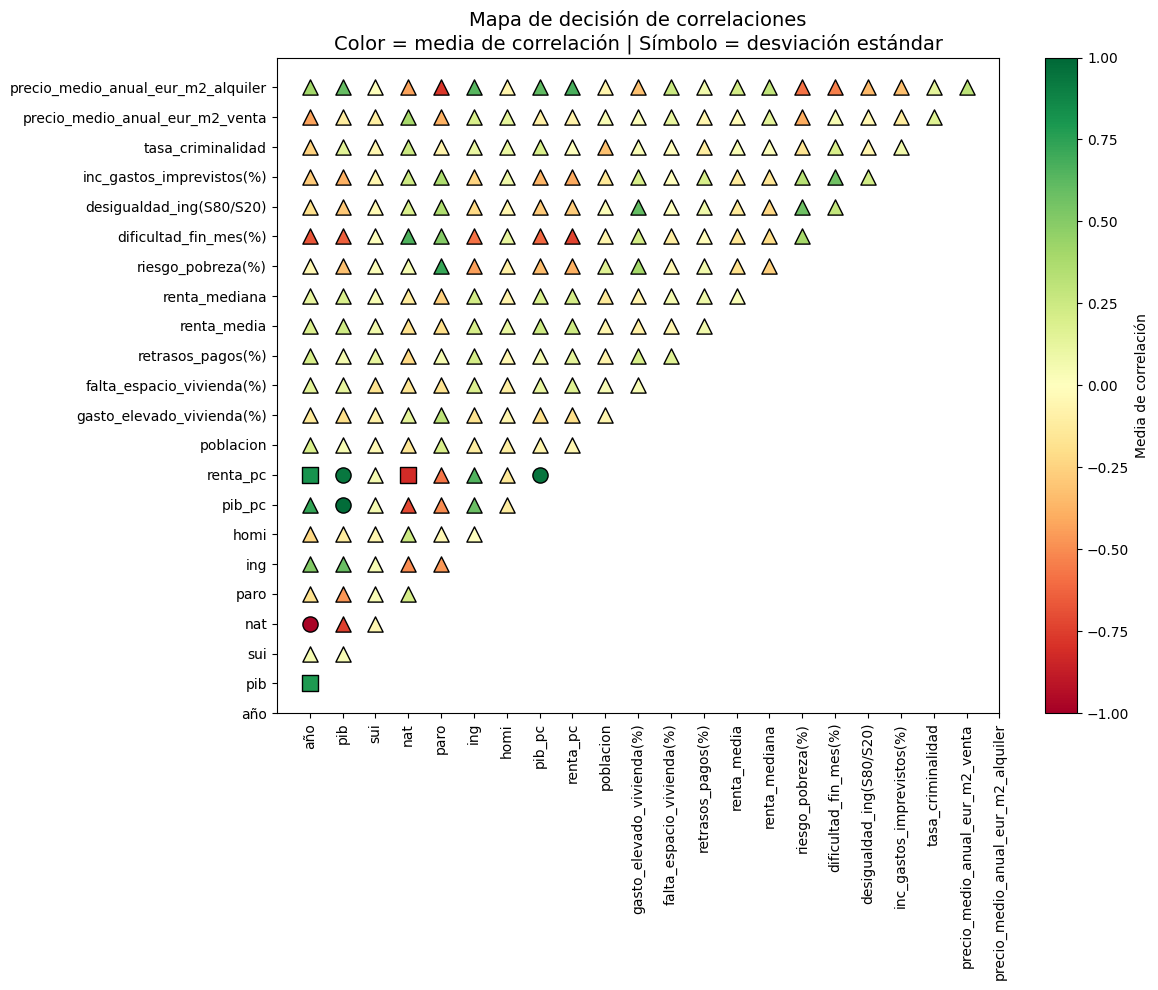

In [108]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in corr_summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",     # círculo
        "medium": "s",  # cuadrado
        "high": "^"     # triángulo
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black"
    )

# Ejes
ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media de correlación | Símbolo = desviación estándar",
    fontsize=14
)

# Barra de color
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


*Tras esta primera representación se observan muchos triángulos y pocas variables con una correlación alta. Tras una busqueda en Internet se aplican diferentes palancas para conseguir evidencias relacionales más claras*

🔹 PALANCA 1 — Fisher Z-transform (CLAVE)

Promediar correlaciones en r es mala idea.

Solución:

Transformar primero:

r → z

promediar

volver a r

🔹 Qué hace Fisher Z

Transforma:

𝑧
=
tanh
⁡
−
1
(
𝑟
)
z=tanh
−1
(r)

Propiedades clave:

Distribución aproximadamente normal

Varianza independiente del valor de r

Pensado EXACTAMENTE para:

comparar

promediar

hacer meta-análisis

Después:

𝑟
=
tanh
⁡
(
𝑧
)
r=tanh(z)

👉 No cambia la correlación, cambia cómo la agregas.

🔹 Cuándo usar Fisher Z

✔️ Siempre que:

Promedias correlaciones

Comparas correlaciones entre muestras

Quieres estabilidad estadística

📌 En tu caso: obligatorio, no opcional.

In [109]:
from numpy import arctanh, tanh

z_vectors = corr_vectors.apply(np.arctanh)
z_mean = z_vectors.mean()
z_std = z_vectors.std()

summary = pd.DataFrame({
    "mean": np.tanh(z_mean),
    "std": z_std
})

🔹 PALANCA 2 — Relajar el concepto de “estabilidad”

Ahora mismo estás siendo muy duro.

Ejemplo más realista:

In [110]:
def std_category(std):
    if std < 0.10:
        return "low"
    elif std < 0.20:
        return "medium"
    else:
        return "high"


🔹 PALANCA 3 — Estabilidad de signo (muy potente)

Aunque el valor fluctúe, ¿el signo se mantiene?

In [111]:
sign_consistency = (corr_vectors > 0).mean().abs()

🔹 PALANCA 4 — Filtrar por magnitud mínima

Muchas correlaciones son “ruido pequeño”.

In [112]:
mask = corr_vectors.abs().mean() > 0.2
corr_vectors = corr_vectors.loc[:, mask]

4️⃣ Código COMPLETO aplicando 1–2–3–4

4.1 Fisher Z + estadísticas

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fisher Z transform
z_vectors = corr_vectors.apply(np.arctanh)

summary = pd.DataFrame({
    "mean_r": np.tanh(z_vectors.mean()),   # media correcta
    "std_z": z_vectors.std(),               # variabilidad real
    "sign_consistency": (corr_vectors > 0).mean().abs()
})


4.2 Filtrar por magnitud (palanca 4)

In [114]:
summary = summary[summary["mean_r"].abs() > 0.2]

In [115]:
summary

mean_r  \
año                             pib                                 0.792717   
                                nat                                -0.985744   
                                ing                                 0.546629   
                                homi                               -0.259832   
                                pib_pc                              0.746972   
...                                                                      ...   
dificultad_fin_mes(%)           precio_medio_anual_eur_m2_alquiler -0.662432   
desigualdad_ing(S80/S20)        inc_gastos_imprevistos(%)           0.261882   
                                precio_medio_anual_eur_m2_alquiler -0.396385   
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_alquiler -0.397741   
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler  0.386982   

                                                                       std_z  \
año                             pib                                 0.197007   
                                nat                                 0.407261   
                                ing                                 0.332427   
                                homi                                0.355433   
                                pib_pc                              0.220101   
...                                                                      ...   
dificultad_fin_mes(%)           precio_medio_anual_eur_m2_alquiler  0.746779   
desigualdad_ing(S80/S20)        inc_gastos_imprevistos(%)           0.438739   
                                precio_medio_anual_eur_m2_alquiler  0.389977   
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_alquiler  0.534474   
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler  0.557885   

                                                                    sign_consistency  
año                             pib                                         1.000000  
                                nat                                         0.000000  
                                ing                                         1.000000  
                                homi                                        0.263158  
                                pib_pc                                      1.000000  
...                                                                              ...  
dificultad_fin_mes(%)           precio_medio_anual_eur_m2_alquiler          0.105263  
desigualdad_ing(S80/S20)        inc_gastos_imprevistos(%)                   0.789474  
                                precio_medio_anual_eur_m2_alquiler          0.210526  
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_alquiler          0.210526  
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler          0.736842  

[112 rows x 3 columns]

4.3 Clasificar estabilidad (palanca 2)

In [116]:
def std_category(std):
    if std < 0.20:
        return "low"
    elif std < 0.40:
        return "medium"
    else:
        return "high"

summary["std_cat"] = summary["std_z"].apply(std_category)


5️⃣ Código de la GRÁFICA (final)

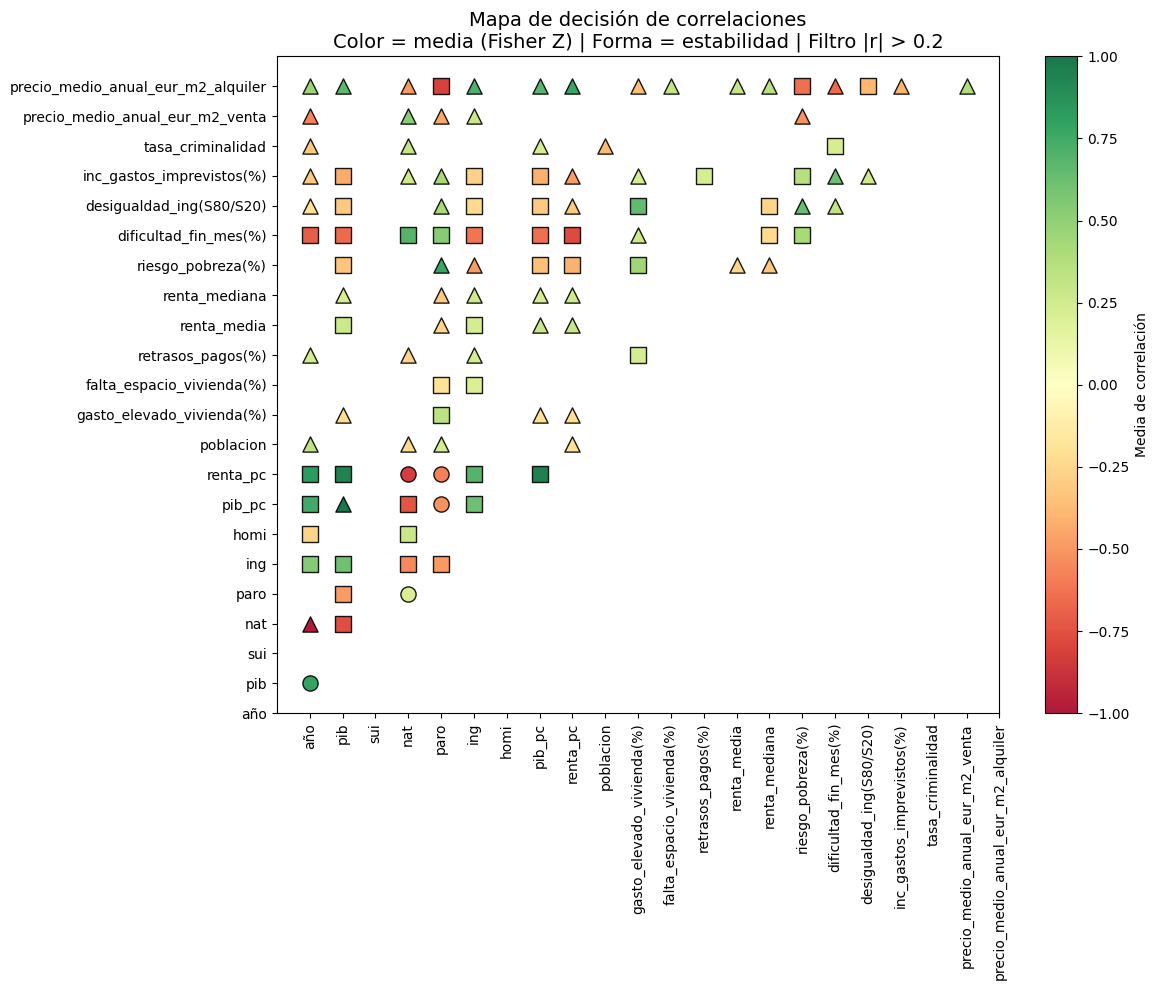

In [117]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x, y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media (Fisher Z) | Forma = estabilidad | Filtro |r| > 0.2",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


*Para una mayor agilidad en el análisis se crea la matriz simétrica y así tener el cuadro completo a la hora de buscar correlaciones.*

In [118]:
summary_sym = summary.copy()

# Intercambiar los pares (A, B) → (B, A)
summary_sym.index = pd.MultiIndex.from_tuples(
    [(j, i) for i, j in summary.index],
    names=summary.index.names
)

# Unir original + simétrica
summary_full = pd.concat([summary, summary_sym])


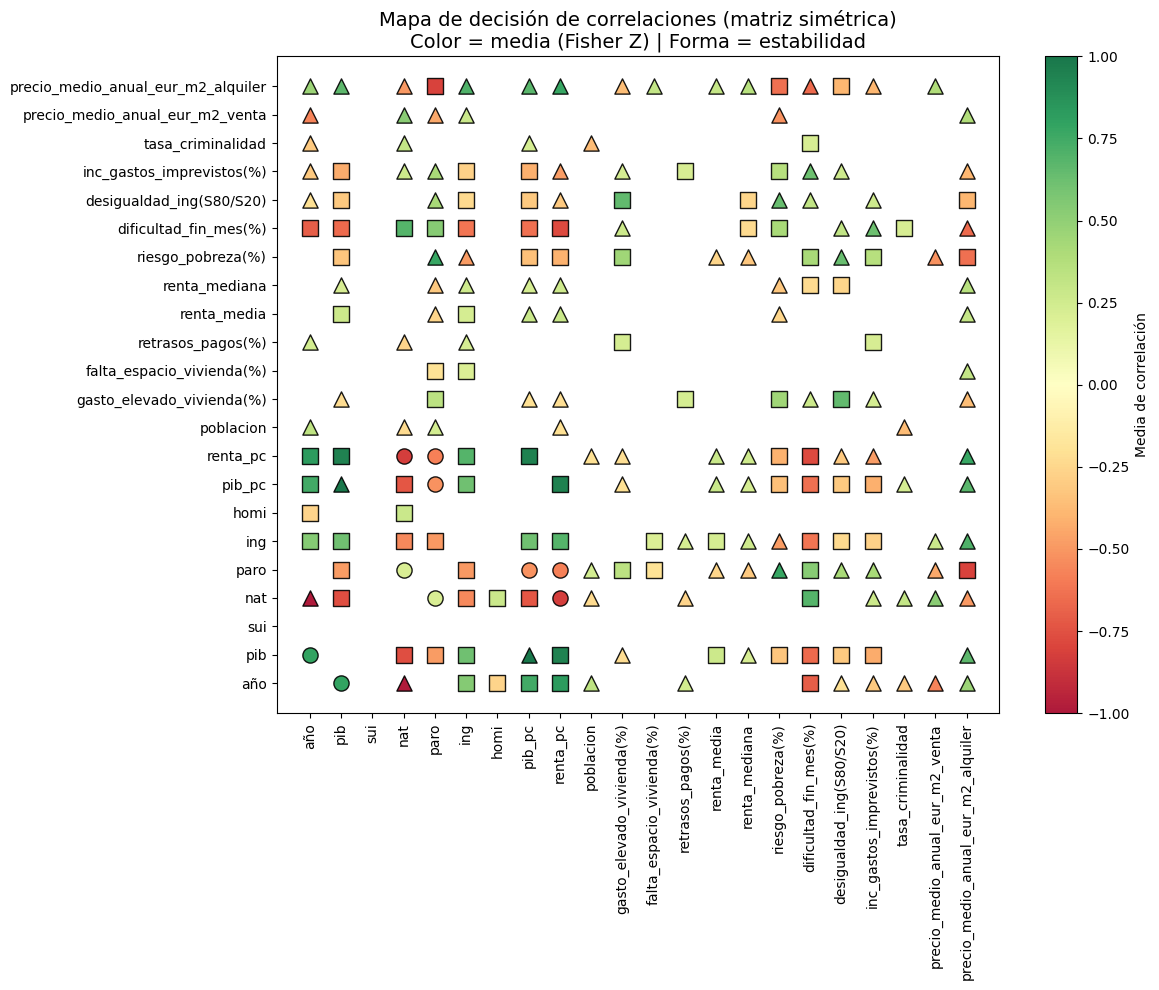

In [119]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary_full.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones (matriz simétrica)\n"
    "Color = media (Fisher Z) | Forma = estabilidad",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


## PIB por Año

Con los resultados obtenidos en la anterior tabla se verifica que existe una alta correlación positiva entre el PIB y el año, de modo que a medida que han pasado los años el PIB ha crecido de manera estable y con poca variación en todas las comunidades autónomas. Para verificar esto, haremos un análisis más en profundidad de estas dos variables, desgranando por cada comunidad y buscando aquellos valores más representativos.

In [120]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))

from src import utils as ut

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
'''
plot_com_variable(df, comunidades, variables, tipo = 'linea')
plot_todas_comunidades(df, variable, comunidades=None)
plot_dual_axis(df, comunidad, var1, var2, x="año")
correlacion_com_bivariante(df, comunidades, variable1, variable2,alpha = 0.05)
'''
from src import utils as ut

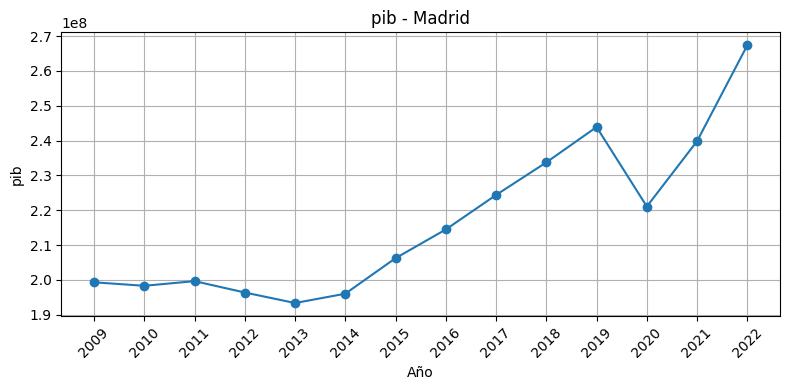

In [122]:
ut.plot_com_variable(df, ['Madrid'], ['pib']);

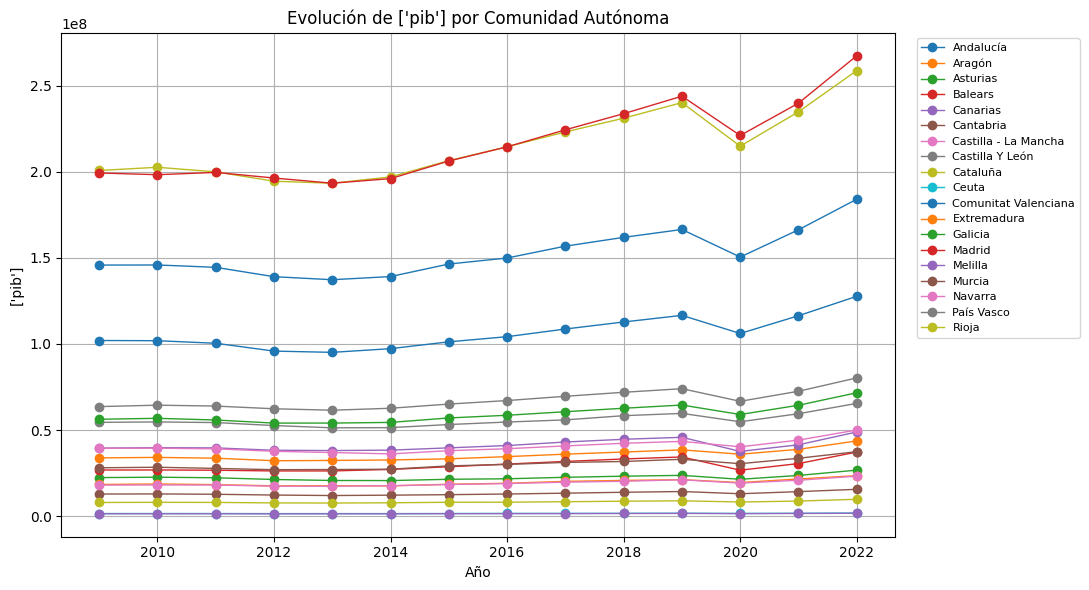

In [123]:
ut.plot_todas_comunidades(df, ['pib']);

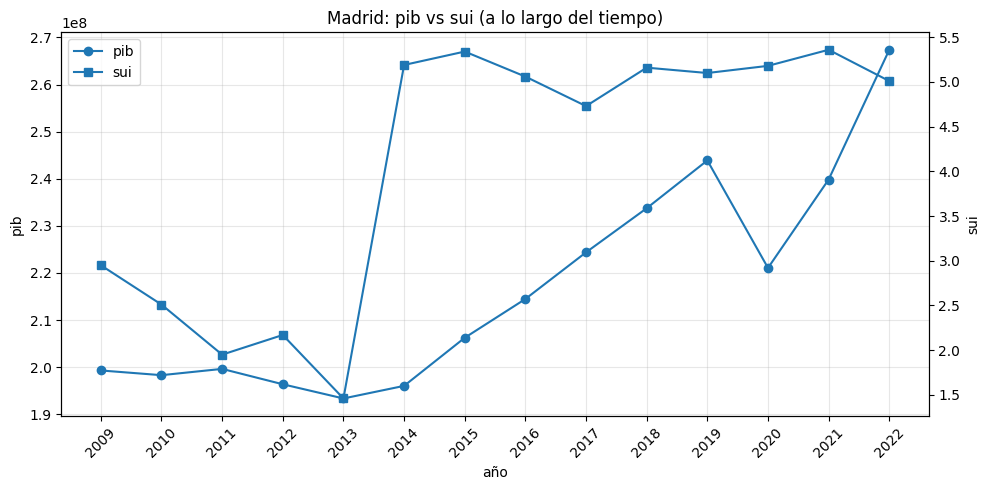

In [124]:
ut.plot_dual_axis(df, ['Madrid'], 'pib', 'sui')

In [125]:
ut.correlacion_com_bivariante(df, df['com_aut'].unique(), 'pib', 'sui')

En Andalucía, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Aragón, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Asturias, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Balears, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Canarias, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Cantabria, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Castilla - La Mancha, para las variables pib y sui interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Castil

*Analizamos la correlación obtenida en cada una de las comunidades para representar aquellos valores que parezcan más interesantes.*

In [126]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '----', datos.loc['año', 'pib'])

Andalucía ---- 0.796476555723015
Aragón ---- 0.8050340359248687
Asturias ---- 0.5548382016226177
Balears ---- 0.7397677809225605
Canarias ---- 0.6142500699884125
Cantabria ---- 0.7422843185562694
Castilla - La Mancha ---- 0.723787423616433
Castilla Y León ---- 0.7152098389279955
Cataluña ---- 0.8499569188532631
Ceuta ---- 0.8097362487475099
Comunitat Valenciana ---- 0.8036390072190042
Extremadura ---- 0.8257845678266488
Galicia ---- 0.8177892430409262
Madrid ---- 0.8795514355743195
Melilla ---- 0.8705541800143266
Murcia ---- 0.8562036367904621
Navarra ---- 0.8379419279311899
País Vasco ---- 0.8232015146613644
Rioja ---- 0.781366654843916


*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Madrid y Melilla), aquellos con menor (Asturias y Canarias) y uno intermedio (Rioja) para tener una idea aproximada del conjunto de valores.*

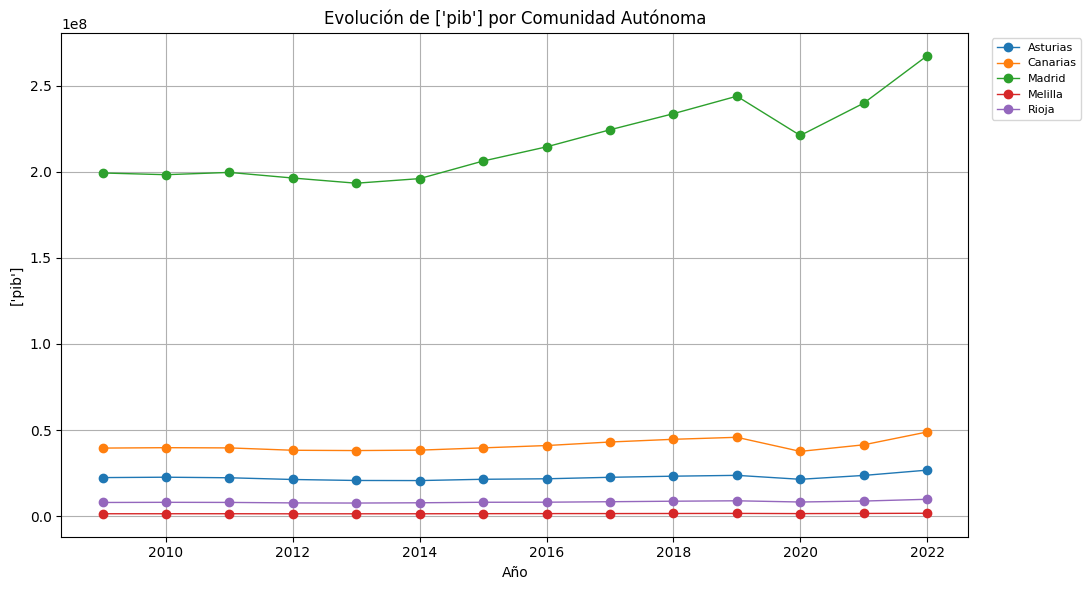

In [130]:
ut.plot_todas_comunidades(df, ['pib'], ['Asturias', 'Canarias', 'Madrid', 'Melilla', 'Rioja']);

*Existe gran disparidad entre los valores representados ya que el PIB de Madrid es notablemente superior a las del resto, para amortiguar en parte esta representación, utilizaremos el PIB per Cápita.*

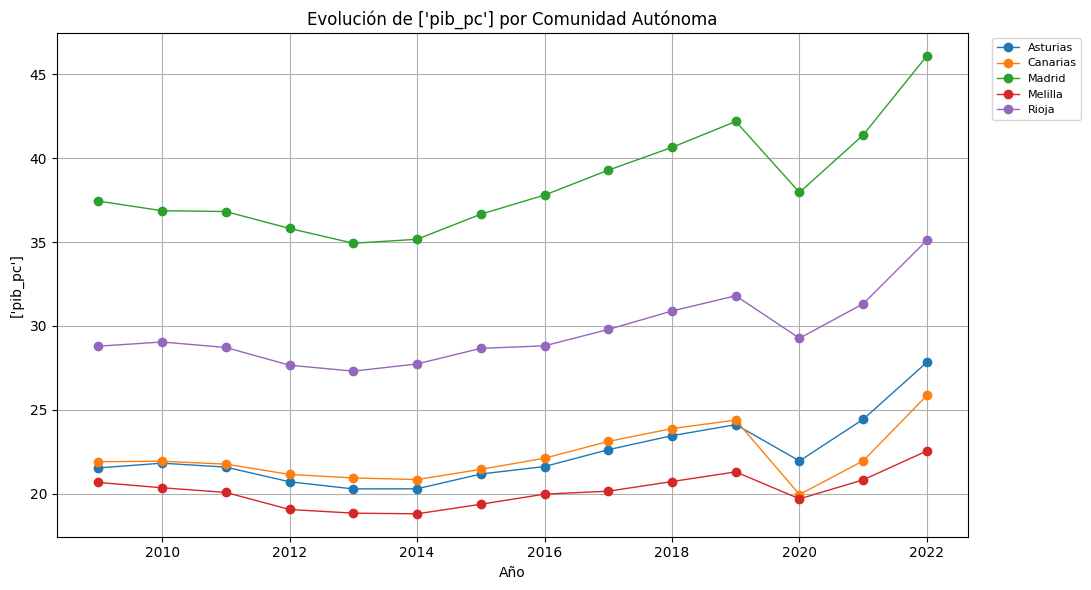

In [131]:
ut.plot_todas_comunidades(df, ['pib_pc'], ['Asturias', 'Canarias', 'Madrid', 'Melilla', 'Rioja']);


*En esta gráfica se puede observar claramente lo que se intuía en la anterior, con los valores más cercanos entre si y permitiendonos ver de un simple vistazo el comportamiento de estos. El PIB es una variable que tiende a crecer con el tiempo, al menos durante los años de muestreo de este dataset. En todas las comunidades existe una clara tendencia ascendente, bache en el camino.*

*Para poder tener en consideración la gráfica anterior donde se representa el pib_pc a lo largo de los años, sería conveniente ver la evolución de la población a lo largo de los años en estas mismas comunidades.*

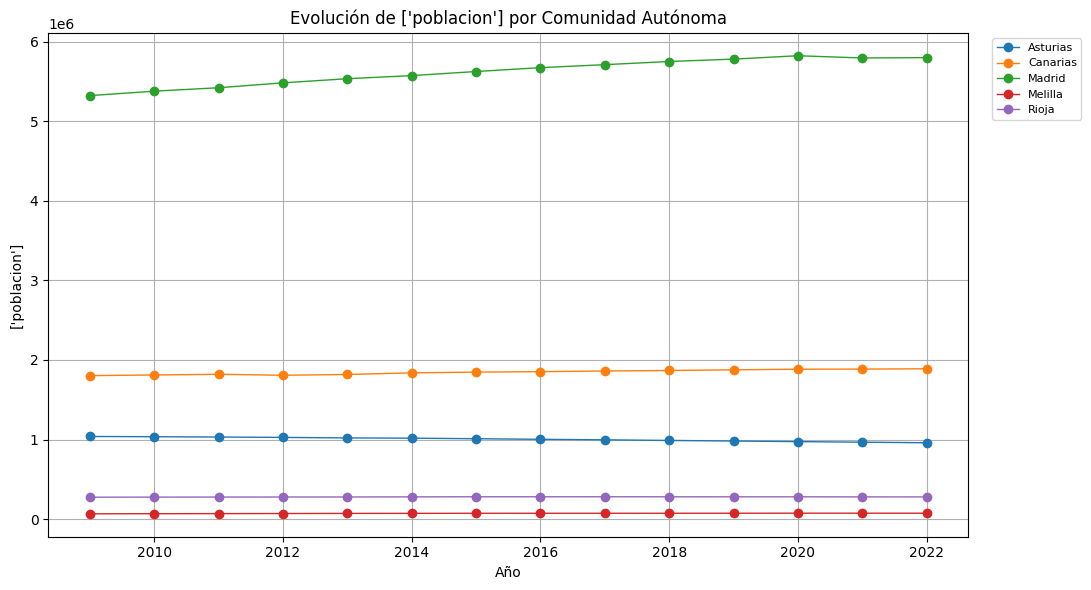

In [134]:
ut.plot_todas_comunidades(df, ['poblacion'], ['Asturias', 'Canarias', 'Madrid', 'Melilla', 'Rioja']);

*Con la información proporcionada por esta gráfica vemos que la población es una serie con una varianza mayor a lo largo de los años, en comunidades como Madrid tiene una clara tendencia ascendente, sin embargo, en Asturias este tendencia es claramente descendente, aunque en cualquier caso son valores relativamente constantes, que nos permiten amortiguar la diferencia de PIB bruto por comunidad para tomar la gráfica anterior como un buen valor de referencia.*

In [135]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '----', datos.loc['año', 'poblacion'])

Andalucía ---- 0.8433097623217969
Aragón ---- -0.7321427517541022
Asturias ---- -0.9943299259971858
Balears ---- 0.9908887046004146
Canarias ---- 0.9807829731434297
Cantabria ---- -0.8114451077000943
Castilla - La Mancha ---- -0.4835986018474175
Castilla Y León ---- -0.9939713280798625
Cataluña ---- 0.9313814714847053
Ceuta ---- 0.5773895533390876
Comunitat Valenciana ---- 0.965446364826127
Extremadura ---- -0.9575439120284602
Galicia ---- -0.9967838600429156
Madrid ---- 0.9786882430327865
Melilla ---- 0.9117762239184759
Murcia ---- 0.998075379866932
Navarra ---- 0.937760960680802
País Vasco ---- -0.273248481959851
Rioja ---- 0.7081587572462942


#### Existe una correlación positiva entre PIB y Año

* En todas las comunidades se observa un crecimiento más o menos regular del PIB a lo largo de los años.
* Existe un año en que todas ellas reducen su PIB, en 2020, año donde estalló la pandemia y paró durante meses el funcionamiento normal del país.
* Durante el resto de datos no existen reducciones de PIB ya que coinciden con todos los años posteriores a la crisis del ladrillo de 2008, donde el país se encuentra en una paulatina y lenta recuperación.
* Comunidades más grandes son capaces de aumentar más su PIB y seguir desarrollandose, aumentando su población, con el ejemplo de Madrid.
* Comunidades más pequeñas tienen más problemas para aumentar su PIB, perdiendo población a lo largo del tiempo como Asturias.
* La tendencia del PIB per Cápita es muy similar en todas ellas, donde el PIB crece más rápido lo hace a costa de un aumento de población. Donde el PIB crece más lento existe una pérdida de población.
* Existen grandes desigualdades en PIB per Cápita para las distintas comunidades autónomas.
* Existen fuertes tendencias positivas o negativas en la población en cada comunidad autónoma, lo que indica un futuro problema social, aumentando la centralización de la población y las zonas vaciadas.